311 Map
=======
Here we're going to load the 311 data that we already saved and then
join it with zip code geographies to make some maps.

We make a quick static map using matplotlib (`plot()`) because GeoPandas
interactive maps struggle with so many points.

**In this notebook:**
- read .csv from a file
- convert latitude and longitude columns into geospatial points
- convert a "regular" DataFrame to a GeoDataFrame
- use a "categorical" color map to make a thematic map using `plot()`
- save the data as a geojson file for use in other programs like QGIS


In [1]:
import pandas as pd
import geopandas as gpd
from shapely import Point

In [2]:
# load the 311 data from the file we saved
df = pd.read_csv("nyc-311.csv", low_memory=False)
display(df.columns)

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip',
       'incident_address', 'street_name', 'cross_street_1', 'cross_street_2',
       'intersection_street_1', 'intersection_street_2', 'address_type',
       'city', 'landmark', 'facility_type', 'status', 'due_date',
       'resolution_description', 'resolution_action_updated_date',
       'community_board', 'bbl', 'borough', 'x_coordinate_state_plane',
       'y_coordinate_state_plane', 'open_data_channel_type',
       'park_facility_name', 'park_borough', 'vehicle_type',
       'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name',
       'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment',
       'latitude', 'longitude', 'location'],
      dtype='object')

In [3]:
# let's copy() the parking complaints into a new dataframe
parking = df[df["complaint_type"] == "Illegal Parking"].copy()
# get just the parking complaints with a zipcode
parking = parking[parking["incident_zip"].notnull()]
# let's see the descriptors
display(parking["descriptor"].value_counts())

descriptor
Blocked Hydrant                   45222
Posted Parking Sign Violation     39800
Blocked Sidewalk                  26233
Commercial Overnight Parking      13622
Double Parked Blocking Traffic     9433
Blocked Crosswalk                  9061
Parking Permit Improper Use        6884
Blocked Bike Lane                  6110
License Plate Obscured             4611
Double Parked Blocking Vehicle     4475
Paper License Plates               2082
Unauthorized Bus Layover           1387
Overnight Commercial Storage       1179
Detached Trailer                    469
Name: count, dtype: int64

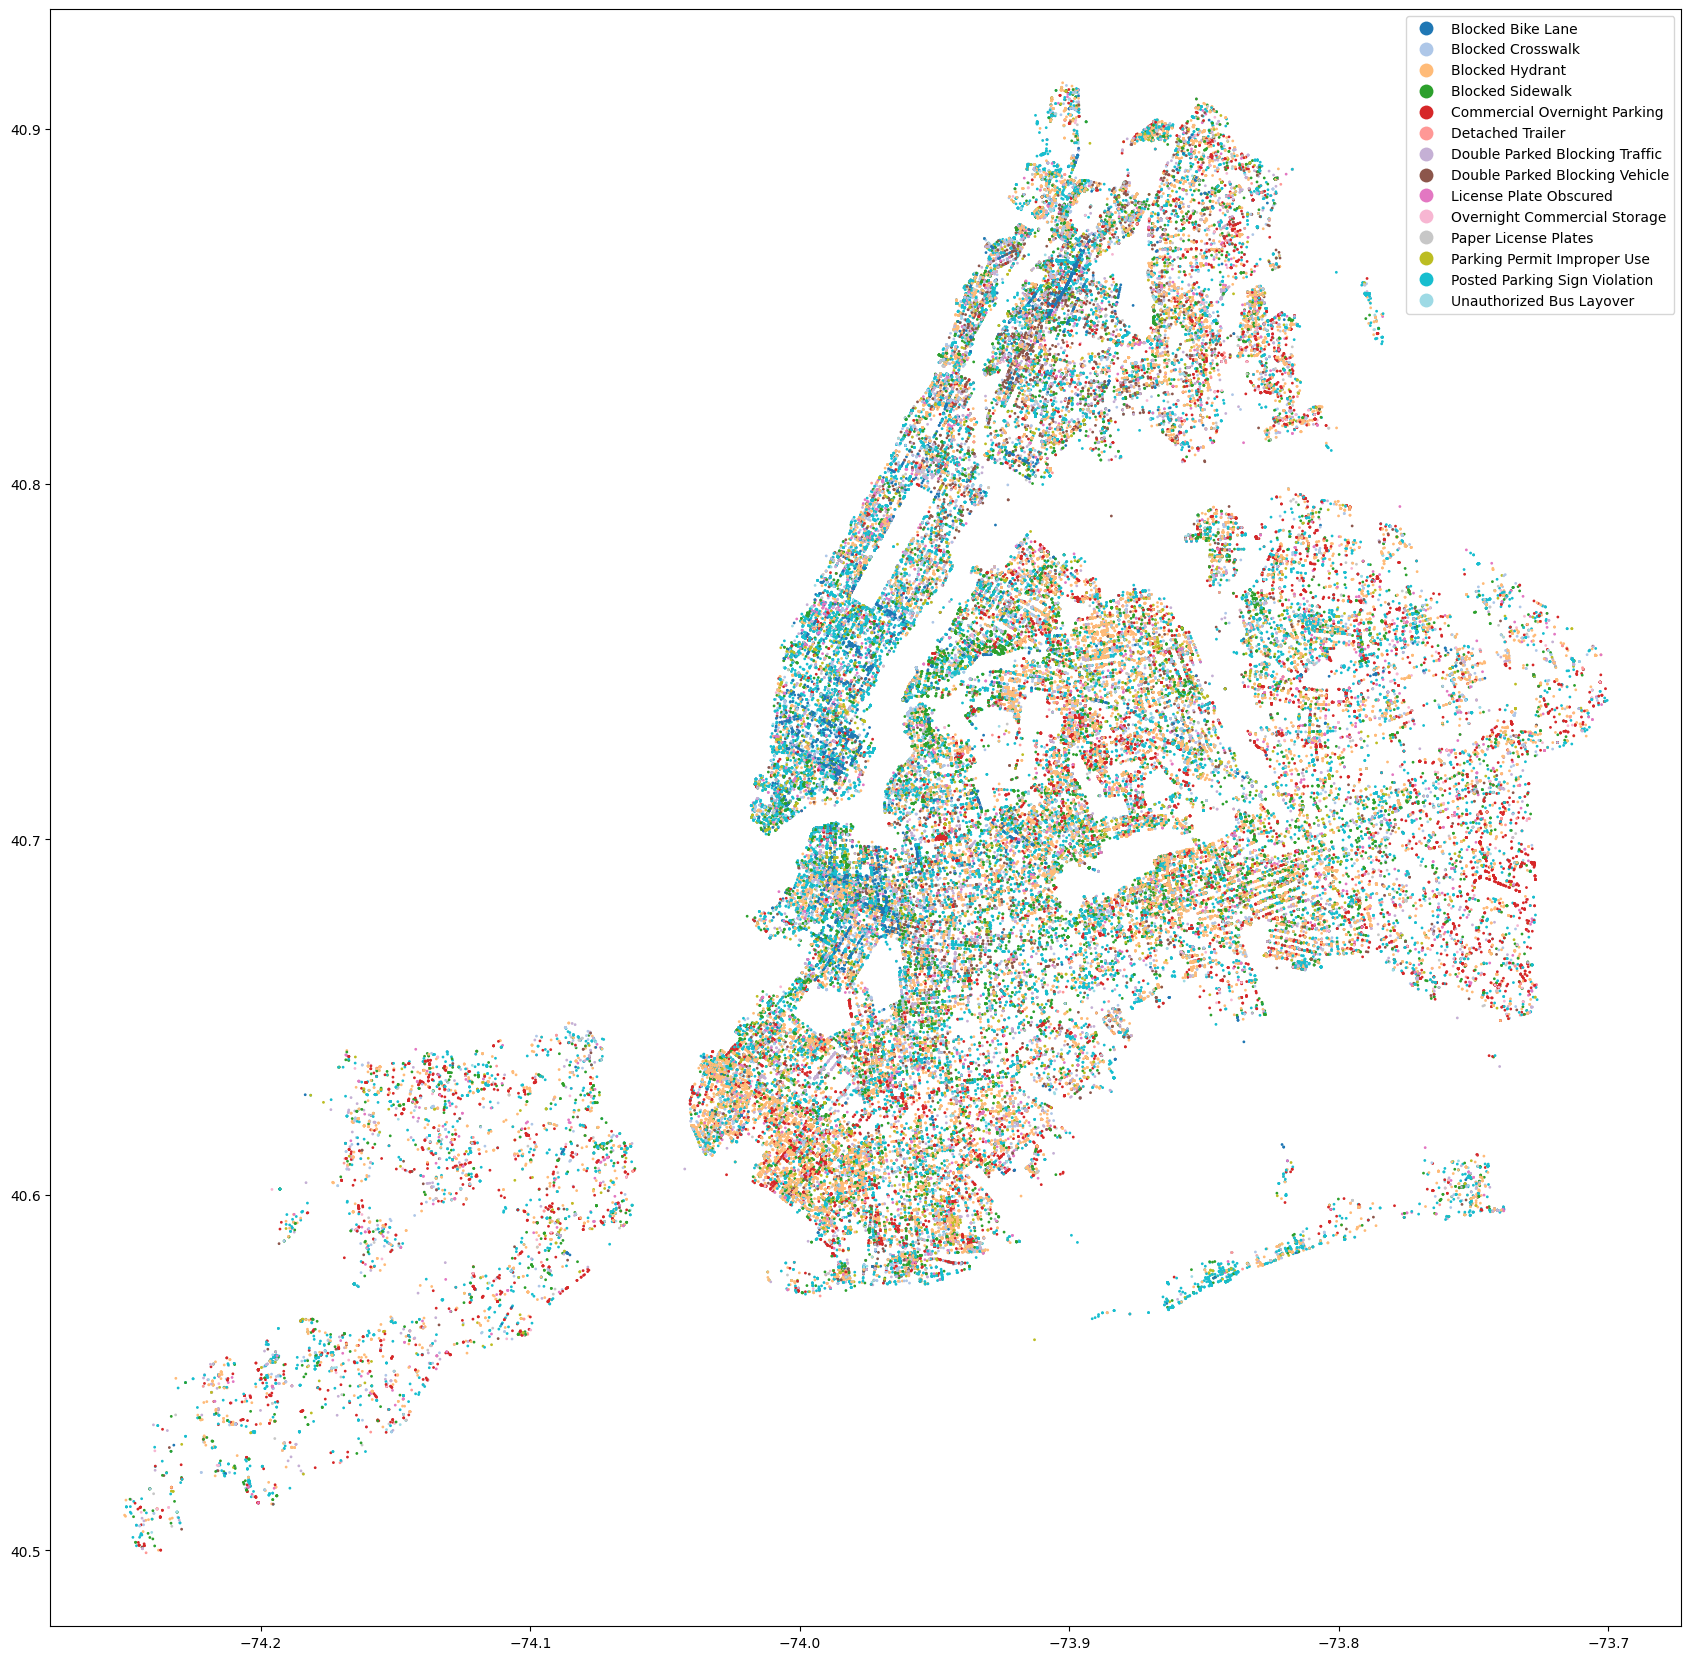

In [4]:
# convert lat,long data into geospatial points

parking["geometry"] = parking.apply(lambda row: Point(row.longitude, row.latitude), axis=1)
parking = gpd.GeoDataFrame(parking, geometry="geometry", crs="EPSG:4326")
parking.plot(column="descriptor", cmap="tab20", figsize=(27,21), markersize=1, legend=True)

# save it as geojson for qgis or other analysis
parking.to_file("nyc-311-parking.geojson", driver="GeoJSON")